In [17]:
from functools import reduce
from typing import TypedDict, List, Literal
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [11]:
def process_values(state: AgentState) -> AgentState:
    """This function process multiple different inputs"""
    state["result"] = f"Hi there {state['name']}, your sum is {sum(state['values'])}."
    return state

In [ ]:
graph = StateGraph(state_schema=AgentState)

graph.add_node(node="process_values", action=process_values)
graph.set_entry_point(key="process_values")
graph.set_finish_point(key="process_values")

app = graph.compile()

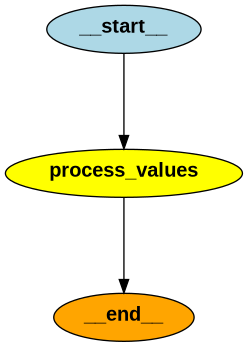

In [13]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_png()))

In [15]:
result = app.invoke(input={"values": [1, 2, 3, 4], "name": "Rajesh"})

In [16]:
result

{'values': [1, 2, 3, 4],
 'name': 'Rajesh',
 'result': 'Hi there Rajesh, your sum is 10.'}

# Excercise

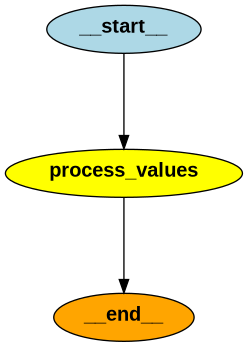

In [19]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str
    operation: Literal["+", "*"]


def process_values(state: AgentState) -> AgentState:
    """This function process multiple different inputs"""
    if state["operation"] == "+":
        state["result"] = (
            f"Hi there {state['name']}, your sum is {sum(state['values'])}."
        )
    else:
        state["result"] = (
            f"Hi there {state['name']}, your sum is {reduce(lambda x, y: x * y, state['values'])}."
        )
    return state


graph = StateGraph(state_schema=AgentState)

graph.add_node(node="process_values", action=process_values)
graph.set_entry_point(key="process_values")
graph.set_finish_point(key="process_values")

app = graph.compile()

display(Image(app.get_graph().draw_png()))

In [21]:
result = app.invoke(input={"values": [1, 2, 3, 4], "name": "Rajesh", "operation": "*"})

In [22]:
result

{'values': [1, 2, 3, 4],
 'name': 'Rajesh',
 'result': 'Hi there Rajesh, your sum is 24.',
 'operation': '*'}